<a href="https://colab.research.google.com/github/dsaezs/Machine-Learning/blob/keras/ejemplo_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto California Housing
Plan de Acción:

Paso 1: Cargar y Entender los Datos.

Paso 2: Preprocesar los Datos (limpieza y normalización).

Paso 3: Construir el Modelo de Red Neuronal con Keras.

Paso 4: Entrenar el Modelo.

Paso 5: Evaluar el rendimiento del Modelo.

Paso 6: Usar el modelo para hacer predicciones.



## Paso 1: Cargar y Entender los Datos
Para este proyecto, usaremos el set de datos "California Housing", un reemplazo moderno y más amplio del clásico set de datos de Boston. Afortunadamente, está incluido en la librería scikit-learn, que ya viene instalada en Colab.

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

In [ ]:
# Cargar el set de datos
# as_frame=True carga los datos directamente en un DataFrame de pandas
california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame

In [ ]:
# Explorar los datos
# Muestra las primeras 5 filas para tener una idea general
print("--- Primeras 5 filas del DataFrame ---")
print(df.head())
print("\n")

--- Primeras 5 filas del DataFrame ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  




In [ ]:
# Muestra información general: número de filas, columnas y si hay valores nulos
print("--- Información general del DataFrame ---")
df.info()
print("\n")

--- Información general del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB




In [ ]:
# Muestra estadísticas descriptivas (media, desviación estándar, etc.)
print("--- Estadísticas Descriptivas ---")
print(df.describe())

--- Estadísticas Descriptivas ---
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956 

##Paso 2: Preprocesar los Datos (limpieza y normalización).

In [ ]:
# Importar las librerías necesarias para el preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np # Lo importamos para las verificaciones opcionales

# 1. Separar características (X) y la variable objetivo (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 2. Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Escalar los datos
scaler = StandardScaler()
scaler.fit(X_train) # Ajustar SOLO con los datos de entrenamiento

# Transformar ambos conjuntos con el escalador ajustado
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Verificaciones Opcionales ---
print("--- Verificación del Preprocesamiento ---")
print("Forma de X_train_scaled:", X_train_scaled.shape)
print("Forma de X_test_scaled:", X_test_scaled.shape)
# La media de cualquier columna en los datos escalados de entrenamiento debería ser cercana a 0
print("Media de la primera columna en X_train_scaled:", np.mean(X_train_scaled[:, 0]))
# La desviación estándar debería ser cercana a 1
print("Desviación estándar de la primera columna en X_train_scaled:", np.std(X_train_scaled[:, 0]))

--- Verificación del Preprocesamiento ---
Forma de X_train_scaled: (16512, 8)
Forma de X_test_scaled: (4128, 8)
Media de la primera columna en X_train_scaled: -6.51933287715935e-17
Desviación estándar de la primera columna en X_train_scaled: 0.9999999999999998


##Paso 3: Construir y Compilar el Modelo con Keras
Aquí es donde diseñamos la "mente" de nuestro sistema. Crearemos una red neuronal simple pero efectiva. Usaremos un modelo Sequential, que es como apilar capas de legos, una encima de la otra.

Nuestra arquitectura será:
- Una capa de entrada que acepta nuestras 8 características.
- Dos capas ocultas que procesarán la información. Usaremos la función de activación ReLU, muy común en deep learning.
-Una capa de salida con una sola neurona que nos dará la predicción final del precio.

In [ ]:
# Importar las clases necesarias de Keras (que ahora vive dentro de TensorFlow)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# --- A. Definir la Arquitectura del Modelo ---

# 1. Crear un modelo Secuencial. Es el tipo de modelo más simple, una pila lineal de capas.
model = Sequential()

# 2. Añadir las capas
# Capa de entrada/oculta 1: 64 neuronas, espera 8 variables de entrada (nuestras 8 columnas).
# La función de activación 'relu' es un estándar moderno que funciona muy bien.
model.add(Dense(64, input_shape=(8,), activation='relu'))

# Capa oculta 2: 32 neuronas. No necesita el input_shape, Keras lo calcula automáticamente.
model.add(Dense(32, activation='relu'))

# Capa de salida: 1 neurona, ya que queremos predecir un único valor (el precio).
# No tiene función de activación (o es 'linear') porque es un problema de regresión.
# No queremos limitar la salida a un rango específico (como lo haría 'sigmoid' o 'softmax').
model.add(Dense(1))


# --- B. Compilar el Modelo ---

# Aquí configuramos el proceso de aprendizaje.
# optimizer='adam': Es un algoritmo eficiente para encontrar los mejores "pesos" para las neuronas.
# loss='mse': (Mean Squared Error o Error Cuadrático Medio). Es la métrica que el modelo intentará minimizar.
#           Es el estándar para problemas de regresión.
# metrics=['mae']: (Mean Absolute Error o Error Absoluto Medio). Es otra métrica que solo usaremos
#           para monitorear el rendimiento. Es más fácil de interpretar que el 'mse'.
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


# --- C. Visualizar el Modelo ---
# Muestra un resumen de la arquitectura que acabamos de crear.
print("--- Arquitectura del Modelo ---")
model.summary()

--- Arquitectura del Modelo ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

¿Qué significa el model.summary()?
La salida de model.summary() te dará una tabla muy útil que muestra:

Cada capa de tu modelo en orden.

La "forma" de los datos que salen de cada capa.

El número de parámetros entrenables. Estos son los "pesos" o las "perillas" que el modelo ajustará durante el entrenamiento para minimizar el error.

## Paso 4: Entrenar el Modelo
Vamos a tomar nuestros datos de entrenamiento ya procesados y se los daremos al modelo que acabamos de construir para que aprenda a encontrar patrones. Usaremos el método .fit().

Le diremos al modelo que:

Mire los datos de entrenamiento 100 veces (esto se llama epochs). En cada "epoch", el modelo recorre todos los datos de entrenamiento una vez para ajustar sus parámetros.

Procese los datos en lotes de 32 (batch_size). En lugar de analizar las ~16,000 casas de una sola vez, las ve en grupos pequeños, lo cual es más eficiente.

Después de cada epoch, valide su rendimiento con los datos de prueba (validation_data), que nunca ha visto antes. Esto nos permite espiar qué tan bien está generalizando su conocimiento.

In [ ]:
print("--- Iniciando Entrenamiento ---")

# Entrenamos el modelo con nuestros datos.
# Guardamos el resultado del entrenamiento en una variable 'history'
# para poder graficar los resultados después.
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1  # verbose=1 muestra la barra de progreso
)

print("\n--- Entrenamiento Finalizado ---")

--- Iniciando Entrenamiento ---
Epoch 1/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.6574 - mae: 0.8746 - val_loss: 0.4360 - val_mae: 0.4779
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4034 - mae: 0.4524 - val_loss: 0.3963 - val_mae: 0.4422
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4268 - mae: 0.4417 - val_loss: 0.3729 - val_mae: 0.4321
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3680 - mae: 0.4291 - val_loss: 0.3639 - val_mae: 0.4179
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3468 - mae: 0.4176 - val_loss: 0.3519 - val_mae: 0.4203
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3287 - mae: 0.4033 - val_loss: 0.3382 - val_mae: 0.4017
Epoch 7/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3287 - mae: 0.4020 - val_loss: 0.3244 - val_mae: 0.3932
Epoch 8/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3193 - mae: 0.3970 - val_loss: 0.3213 - val_mae: 0.3884
Epoch 9/100
516/

¿Qué verás en pantalla?
Verás una línea de progreso por cada una de las 100 epochs. Para cada una, Keras te mostrará:

loss: El error cuadrático medio (MSE) en los datos de entrenamiento.

mae: El error absoluto medio (MAE) en los datos de entrenamiento.

val_loss: El MSE en los datos de validación/prueba.

val_mae: El MAE en los datos de validación/prueba.

Lo ideal es que todos estos valores, especialmente loss y val_loss, disminuyan con el tiempo. El valor val_mae es muy interesante porque nos dice, en promedio, por cuántos "cientos de miles de dólares" se equivoca nuestro modelo en sus predicciones (ya que el precio está escalado). Por ejemplo, un val_mae de 0.5 significaría un error promedio de $50,000.

## Paso 5: Evaluar y Visualizar el Rendimiento
Ahora que el modelo está entrenado, necesitamos responder dos preguntas clave:

¿Qué tan bien aprendió? (¿Cuál es su error final?)

¿Cómo aprendió? (¿Aprendió de forma estable o empezó a "memorizar"?)

Para ello, usaremos el objeto history que guardamos y el método model.evaluate(). Crearemos un gráfico para ver la evolución del error durante el entrenamiento. Esta es la mejor manera de diagnosticar problemas como el sobreajuste (overfitting).

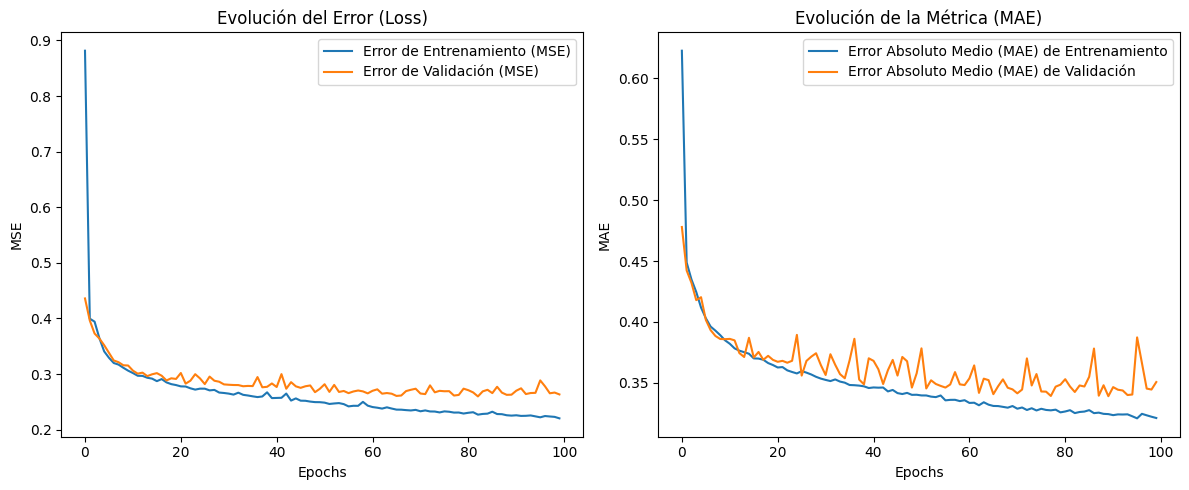


--- Evaluación final sobre el conjunto de prueba ---
Error Cuadrático Medio (Loss/MSE) en prueba: 0.2633
Error Absoluto Medio (MAE) en prueba: 0.3506


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convertir el historial de entrenamiento a un DataFrame de pandas para facilitar la manipulación
history_df = pd.DataFrame(history.history)

# --- Gráfico 1: Evolución del Error (Loss) ---
plt.figure(figsize=(12, 5)) # Crear una figura para los gráficos

# Gráfico para el Error Cuadrático Medio (MSE)
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(history_df.index, history_df['loss'], label='Error de Entrenamiento (MSE)')
plt.plot(history_df.index, history_df['val_loss'], label='Error de Validación (MSE)')
plt.title('Evolución del Error (Loss)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

# --- Gráfico 2: Evolución de la Métrica (MAE) ---
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(history_df.index, history_df['mae'], label='Error Absoluto Medio (MAE) de Entrenamiento')
plt.plot(history_df.index, history_df['val_mae'], label='Error Absoluto Medio (MAE) de Validación')
plt.title('Evolución de la Métrica (MAE)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout() # Ajusta los gráficos para que no se superpongan
plt.show()

# --- Evaluación Final del Modelo ---
# Finalmente, evaluamos el rendimiento del modelo con el conjunto de prueba
print("\n--- Evaluación final sobre el conjunto de prueba ---")
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Error Cuadrático Medio (Loss/MSE) en prueba: {test_loss:.4f}")
print(f"Error Absoluto Medio (MAE) en prueba: {test_mae:.4f}")

### Cómo Interpretar los Resultados

Observa los Gráficos:

Curvas Descendentes: Idealmente, ambas curvas (entrenamiento y validación) deberían bajar y luego estabilizarse (aplanarse). Esto indica que el modelo está aprendiendo.

¿Hay Sobreajuste (Overfitting)? Fíjate si la línea de validación (naranja) sigue de cerca a la de entrenamiento (azul). Si la línea naranja empieza a subir en algún punto mientras la azul sigue bajando, es una señal clara de sobreajuste. Esto significa que el modelo se ha vuelto demasiado bueno memorizando los datos de entrenamiento y ya no generaliza bien a datos nuevos.

Mira la Evaluación Final:

El valor test_mae es tu resultado más importante. Te dice, en promedio, cuál es el error de predicción de tu modelo en los datos de prueba. Recuerda que la variable objetivo está en cientos de miles de dólares, así que un MAE de 0.35 significa un error promedio de $35,000 USD.

### Interpretación de los Gráficos 📊
El modelo aprende correctamente: En ambos gráficos, la línea azul (entrenamiento) y la naranja (validación) bajan drásticamente en las primeras 20-30 epochs y luego se estabilizan. Esto es exactamente lo que queremos ver. Significa que el modelo dejó de ser ignorante y aprendió rápidamente los patrones principales de los datos.

Ligero sobreajuste (Overfitting): Después de la epoch 20 aproximadamente, la línea de validación (naranja) se separa de la de entrenamiento (azul) y se mantiene consistentemente por encima. La línea azul sigue bajando lentamente, mientras que la naranja se queda "estancada" y es más ruidosa.

¿Qué significa esto? El modelo se está volviendo un experto en los datos de entrenamiento (sigue mejorando en ellos), pero su rendimiento en los datos nuevos (de validación) no mejora más. Se está "memorizando" un poco los ejemplos que ya vio, en lugar de generalizar mejor la regla. Es un sobreajuste muy leve y común.

Estabilidad: La curva de validación no "explota" hacia arriba, lo que es una excelente señal. El modelo es estable y su rendimiento es consistente en datos no vistos, aunque no perfecto.

## Interpretación de los Resultados Finales numeric
Error Cuadrático Medio (MSE) en prueba: 0.2633

Este número es difícil de interpretar directamente porque está en "unidades al cuadrado". Principalmente, lo usamos como la función de pérdida que el modelo debe minimizar durante el entrenamiento. Un valor más bajo es mejor.

Error Absoluto Medio (MAE) en prueba: 0.3506

Esta es la métrica clave para nosotros. Un MAE de 0.3506 significa que, en promedio, las predicciones de tu modelo se desvían en $35,060 del precio real de la vivienda (ya que la variable objetivo está en cientos de miles de dólares).

## Paso 6: Hacer Predicciones con Datos Nuevos

El proceso es simple:

Definimos las 8 características de nuestra casa.

Muy importante: Usamos el mismo scaler que creamos antes para transformar estos nuevos datos. El modelo solo entiende datos en la misma escala en que fue entrenado.

Le pasamos los datos escalados a model.predict().

In [ ]:
import numpy as np
import pandas as pd

# 1. Define las características de una nueva casa en un diccionario
#    He puesto valores de una casa "buena": altos ingresos en la zona,
#    no muy vieja, pocas personas por hogar, y en una lat/lon de Los Ángeles.
mi_casa = {
    'MedInc': [3.5],       # Ingreso medio del vecindario (en decenas de miles)
    'HouseAge': [15],      # Antigüedad de la casa en años
    'AveRooms': [6],       # Promedio de habitaciones por hogar
    'AveBedrms': [1.2],    # Promedio de dormitorios por hogar
    'Population': [800],   # Población del vecindario
    'AveOccup': [2.5],     # Promedio de ocupantes por hogar
    'Latitude': [34.05],   # Latitud
    'Longitude': [-118.25] # Longitud
}

# 2. Convertir el diccionario a un DataFrame de Pandas.
#    Debe tener la misma estructura que los datos originales.
mi_casa_df = pd.DataFrame(mi_casa)

# 3. Escalar los datos de la nueva casa con el MISMO escalador que usamos antes.
mi_casa_scaled = scaler.transform(mi_casa_df)

# 4. Hacer la predicción
prediccion = model.predict(mi_casa_scaled)

# 5. Interpretar el resultado
#    El modelo devuelve un valor escalado, lo multiplicamos por 100,000 para obtener el precio en USD.
precio_predicho = prediccion[0][0] * 100000

print(f"\nCaracterísticas de la casa:\n{mi_casa_df.transpose()}")
print("------------------------------------------")
print(f"El precio predicho para esta casa es: ${precio_predicho:,.2f} USD")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

Características de la casa:
                 0
MedInc        3.50
HouseAge     15.00
AveRooms      6.00
AveBedrms     1.20
Population  800.00
AveOccup      2.50
Latitude     34.05
Longitude  -118.25
------------------------------------------
El precio predicho para esta casa es: $255,674.86 USD
